In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.datasets import fashion_mnist

C:\Users\JimmyWu\.conda\envs\fds_cw3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## TensorFlow augmentation 7 methods 

In [2]:
SEED = 42
BATCH_SIZE = 64
EPOCHS = 20

tf.random.set_seed(SEED)
np.random.seed(SEED)


# Model
def build_cnn(input_shape, num_classes, onehot=False):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])

    loss = "categorical_crossentropy" if onehot else "sparse_categorical_crossentropy"
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=loss,
        metrics=["accuracy"]
    )
    return model


# Common augmentation layers (create once)
rot = tf.keras.layers.RandomRotation(0.08)
trans = tf.keras.layers.RandomTranslation(0.08, 0.08)
zm = tf.keras.layers.RandomZoom(0.10)
con = tf.keras.layers.RandomContrast(0.10)


# 8 methods (0~7)
def method0(x, y):
    return x, y

def method1(x, y):
    x = rot(x, training=True)
    return x, y

def method2(x, y):
    x = trans(x, training=True)
    return x, y

def method3(x, y):
    x = zm(x, training=True)
    return x, y

def method4(x, y, is_rgb):
    x = rot(x, training=True)
    x = trans(x, training=True)
    x = zm(x, training=True)
    if is_rgb:
        x = con(x, training=True)
    return x, y

# Method 5: MixUp (one-hot y)
def method5(x, y, num_classes):
    y = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)

    batch_size = tf.shape(x)[0]
    alpha = 0.2

    a = tf.random.gamma([batch_size], alpha)
    b = tf.random.gamma([batch_size], alpha)
    lam = a / (a + b + 1e-8)

    lam_x = tf.reshape(lam, [batch_size, 1, 1, 1])
    lam_y = tf.reshape(lam, [batch_size, 1])

    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)

    x = x * lam_x + x2 * (1.0 - lam_x)
    y = y * lam_y + y2 * (1.0 - lam_y)
    return x, y

# Method 6: CutMix (one-hot y, simple batch-wise)
def method6(x, y, num_classes):
    y = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)

    batch_size = tf.shape(x)[0]
    height = tf.shape(x)[1]
    width = tf.shape(x)[2]
    channels = tf.shape(x)[3]

    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)

    alpha = 1.0
    a = tf.random.gamma([], alpha)
    b = tf.random.gamma([], alpha)
    lam = a / (a + b + 1e-8)

    cut_ratio = tf.sqrt(1.0 - lam)
    cut_w = tf.cast(tf.cast(width, tf.float32) * cut_ratio, tf.int32)
    cut_h = tf.cast(tf.cast(height, tf.float32) * cut_ratio, tf.int32)

    cx = tf.random.uniform([], 0, width, dtype=tf.int32)
    cy = tf.random.uniform([], 0, height, dtype=tf.int32)

    x1 = tf.clip_by_value(cx - cut_w // 2, 0, width)
    x2b = tf.clip_by_value(cx + cut_w // 2, 0, width)
    y1 = tf.clip_by_value(cy - cut_h // 2, 0, height)
    y2b = tf.clip_by_value(cy + cut_h // 2, 0, height)

    xs = tf.range(width)[None, :]
    ys = tf.range(height)[:, None]
    inside = tf.logical_and(
        tf.logical_and(xs >= x1, xs < x2b),
        tf.logical_and(ys >= y1, ys < y2b)
    )

    mask = tf.cast(inside, tf.float32)[None, ..., None]
    mask = tf.broadcast_to(mask, [batch_size, height, width, channels])

    x = x * (1.0 - mask) + x2 * mask

    area = tf.cast((x2b - x1) * (y2b - y1), tf.float32)
    lam_real = 1.0 - area / (tf.cast(height * width, tf.float32) + 1e-8)
    y = y * lam_real + y2 * (1.0 - lam_real)

    return x, y

# Method 7: RandAugment (built-in)
randaugment = tf.keras.layers.RandAugment(
    value_range=(0.0, 1.0),
    num_ops=2,
    factor=0.5
)

def method7(x, y, is_rgb):
    if not is_rgb:
        # 1-channel -> 3-channel
        x = tf.concat([x, x, x], axis=-1)

        # RandAugment needs 3 channels
        x = randaugment(x, training=True)

        # 3-channel -> 1-channel
        x = tf.reduce_mean(x, axis=-1, keepdims=True)
    else:
        x = randaugment(x, training=True)

    return x, y





# Train each method
def run_method(X_train, y_train, X_val, y_val, input_shape, num_classes, method_id, is_rgb):
    use_onehot = (method_id == 5 or method_id == 6)
    model = build_cnn(input_shape, num_classes, onehot=use_onehot)

    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
        .shuffle(min(len(X_train), 20000), seed=SEED) \
        .batch(BATCH_SIZE)

    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)

    methods = [method0, method1, method2, method3, method4, method5, method6, method7]

    def train_map(x, y):
        for i in range(len(methods)):
            if i == method_id:
                if i == 4:
                    return methods[i](x, y, is_rgb)
                elif i in [5, 6]:
                    return methods[i](x, y, num_classes)
                elif i == 7:
                    return methods[i](x, y, is_rgb) 
                else:
                    return methods[i](x, y)


    train_ds = train_ds.map(train_map, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

    if use_onehot:
        def val_map(x, y):
            y = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)
            return x, y
        val_ds = val_ds.map(val_map, num_parallel_calls=tf.data.AUTOTUNE)

    val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

    history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=2)

    final_train_acc = history.history["accuracy"][-1]
    final_val_acc = history.history["val_accuracy"][-1]
    return history, final_train_acc, final_val_acc



# Plot
def plot_acc_loss(history, title_prefix=""):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_final_summary(results_dict, title="Final Train / Val Accuracy by Method"):
    methods = sorted(results_dict.keys())
    train_acc = [results_dict[m][0] for m in methods]
    val_acc = [results_dict[m][1] for m in methods]

    plt.figure(figsize=(8, 5))
    plt.plot(methods, train_acc, marker="o", label="Train Accuracy")
    plt.plot(methods, val_acc, marker="s", label="Validation Accuracy")

    plt.xticks(methods)
    plt.xlabel("Method ID")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

##  Fashion-MNIST



Fashion-MNIST - Method 0
------------------------
Epoch 1/20
875/875 - 5s - 5ms/step - accuracy: 0.8173 - loss: 0.5076 - val_accuracy: 0.8684 - val_loss: 0.3646
Epoch 2/20
875/875 - 4s - 5ms/step - accuracy: 0.8769 - loss: 0.3414 - val_accuracy: 0.8895 - val_loss: 0.3056
Epoch 3/20
875/875 - 4s - 5ms/step - accuracy: 0.8925 - loss: 0.2946 - val_accuracy: 0.8944 - val_loss: 0.2923
Epoch 4/20
875/875 - 4s - 5ms/step - accuracy: 0.9055 - loss: 0.2602 - val_accuracy: 0.9083 - val_loss: 0.2604
Epoch 5/20
875/875 - 4s - 5ms/step - accuracy: 0.9136 - loss: 0.2331 - val_accuracy: 0.9039 - val_loss: 0.2670
Epoch 6/20
875/875 - 4s - 5ms/step - accuracy: 0.9216 - loss: 0.2121 - val_accuracy: 0.9106 - val_loss: 0.2459
Epoch 7/20
875/875 - 4s - 5ms/step - accuracy: 0.9282 - loss: 0.1922 - val_accuracy: 0.9119 - val_loss: 0.2423
Epoch 8/20
875/875 - 4s - 5ms/step - accuracy: 0.9369 - loss: 0.1717 - val_accuracy: 0.9150 - val_loss: 0.2315
Epoch 9/20
875/875 - 4s - 5ms/step - accuracy: 0.9435 - loss

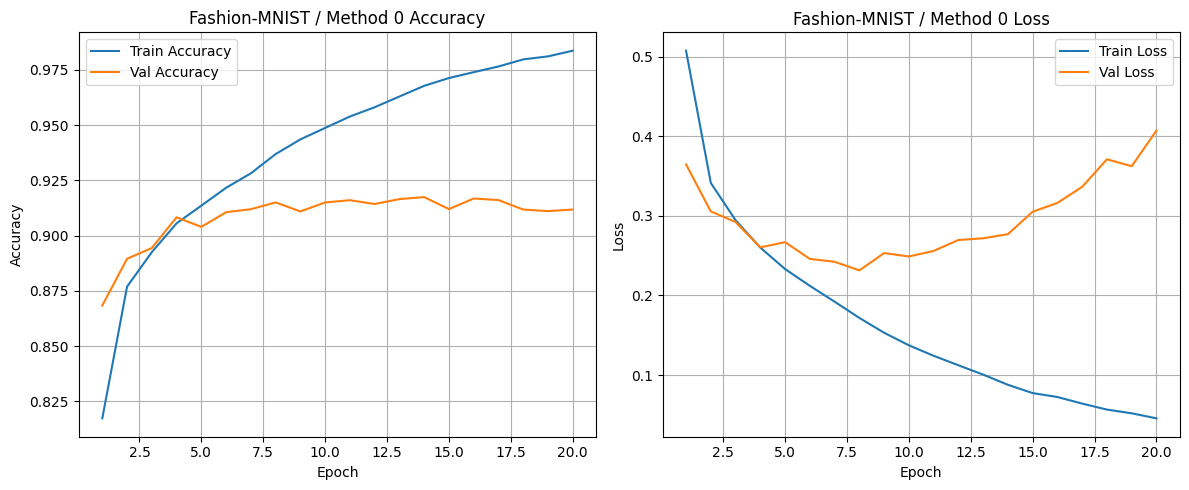



Fashion-MNIST - Method 1
------------------------
Epoch 1/20
875/875 - 5s - 6ms/step - accuracy: 0.7711 - loss: 0.6282 - val_accuracy: 0.8250 - val_loss: 0.4735
Epoch 2/20
875/875 - 4s - 5ms/step - accuracy: 0.8364 - loss: 0.4481 - val_accuracy: 0.8556 - val_loss: 0.4092
Epoch 3/20
875/875 - 4s - 5ms/step - accuracy: 0.8574 - loss: 0.3906 - val_accuracy: 0.8686 - val_loss: 0.3638
Epoch 4/20
875/875 - 4s - 5ms/step - accuracy: 0.8689 - loss: 0.3564 - val_accuracy: 0.8794 - val_loss: 0.3367
Epoch 5/20
875/875 - 4s - 5ms/step - accuracy: 0.8790 - loss: 0.3280 - val_accuracy: 0.8850 - val_loss: 0.3206
Epoch 6/20
875/875 - 4s - 5ms/step - accuracy: 0.8846 - loss: 0.3152 - val_accuracy: 0.8889 - val_loss: 0.3109
Epoch 7/20
875/875 - 4s - 5ms/step - accuracy: 0.8919 - loss: 0.2965 - val_accuracy: 0.8836 - val_loss: 0.3155
Epoch 8/20
875/875 - 4s - 5ms/step - accuracy: 0.8946 - loss: 0.2828 - val_accuracy: 0.8997 - val_loss: 0.2783
Epoch 9/20
875/875 - 4s - 5ms/step - accuracy: 0.9017 - loss

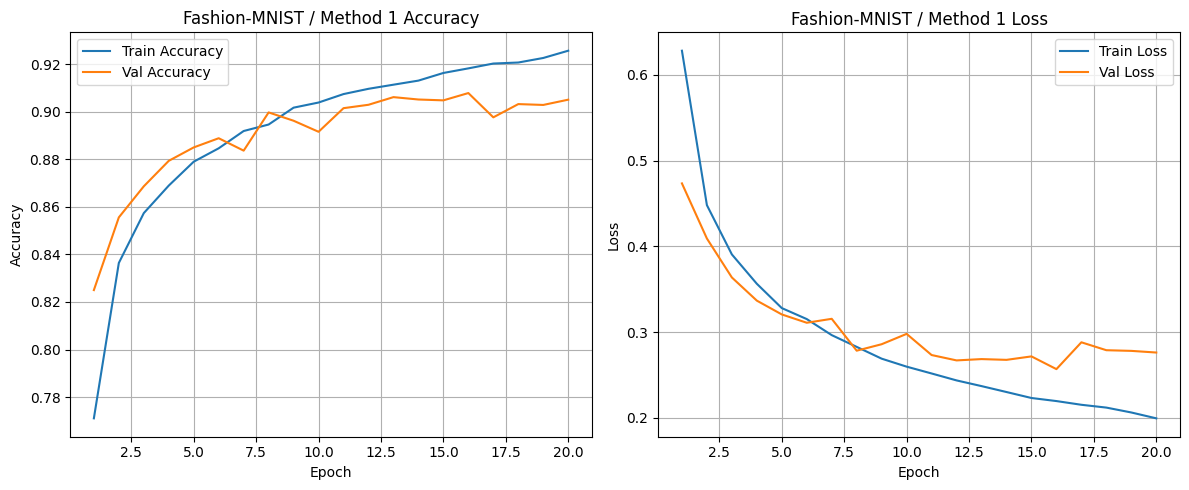



Fashion-MNIST - Method 2
------------------------
Epoch 1/20
875/875 - 5s - 6ms/step - accuracy: 0.7764 - loss: 0.6044 - val_accuracy: 0.8564 - val_loss: 0.3919
Epoch 2/20
875/875 - 4s - 5ms/step - accuracy: 0.8414 - loss: 0.4286 - val_accuracy: 0.8771 - val_loss: 0.3410
Epoch 3/20
875/875 - 4s - 5ms/step - accuracy: 0.8601 - loss: 0.3772 - val_accuracy: 0.8816 - val_loss: 0.3329
Epoch 4/20
875/875 - 4s - 5ms/step - accuracy: 0.8731 - loss: 0.3435 - val_accuracy: 0.8911 - val_loss: 0.3057
Epoch 5/20
875/875 - 4s - 5ms/step - accuracy: 0.8802 - loss: 0.3198 - val_accuracy: 0.8952 - val_loss: 0.2948
Epoch 6/20
875/875 - 4s - 5ms/step - accuracy: 0.8861 - loss: 0.3072 - val_accuracy: 0.8911 - val_loss: 0.2911
Epoch 7/20
875/875 - 4s - 5ms/step - accuracy: 0.8918 - loss: 0.2888 - val_accuracy: 0.9021 - val_loss: 0.2671
Epoch 8/20
875/875 - 4s - 5ms/step - accuracy: 0.8957 - loss: 0.2791 - val_accuracy: 0.9031 - val_loss: 0.2531
Epoch 9/20
875/875 - 4s - 5ms/step - accuracy: 0.9028 - loss

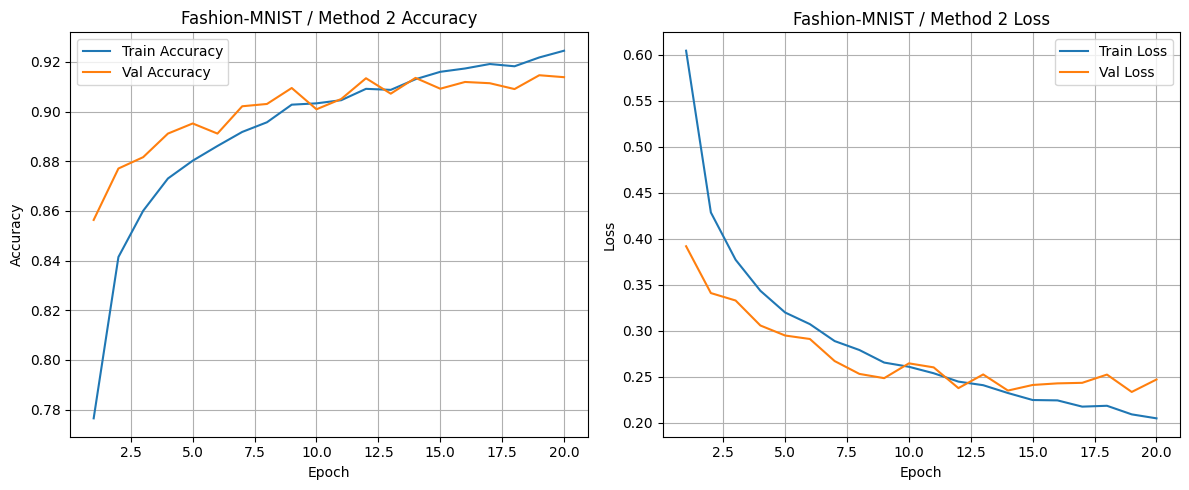



Fashion-MNIST - Method 3
------------------------
Epoch 1/20
875/875 - 5s - 6ms/step - accuracy: 0.8034 - loss: 0.5439 - val_accuracy: 0.8636 - val_loss: 0.3754
Epoch 2/20
875/875 - 4s - 5ms/step - accuracy: 0.8635 - loss: 0.3727 - val_accuracy: 0.8783 - val_loss: 0.3353
Epoch 3/20
875/875 - 4s - 5ms/step - accuracy: 0.8831 - loss: 0.3210 - val_accuracy: 0.8914 - val_loss: 0.3093
Epoch 4/20
875/875 - 4s - 5ms/step - accuracy: 0.8934 - loss: 0.2903 - val_accuracy: 0.8979 - val_loss: 0.2829
Epoch 5/20
875/875 - 4s - 5ms/step - accuracy: 0.9021 - loss: 0.2670 - val_accuracy: 0.8994 - val_loss: 0.2808
Epoch 6/20
875/875 - 4s - 5ms/step - accuracy: 0.9091 - loss: 0.2473 - val_accuracy: 0.9022 - val_loss: 0.2654
Epoch 7/20
875/875 - 4s - 5ms/step - accuracy: 0.9136 - loss: 0.2314 - val_accuracy: 0.9090 - val_loss: 0.2494
Epoch 8/20
875/875 - 4s - 5ms/step - accuracy: 0.9202 - loss: 0.2144 - val_accuracy: 0.9071 - val_loss: 0.2523
Epoch 9/20
875/875 - 4s - 5ms/step - accuracy: 0.9250 - loss

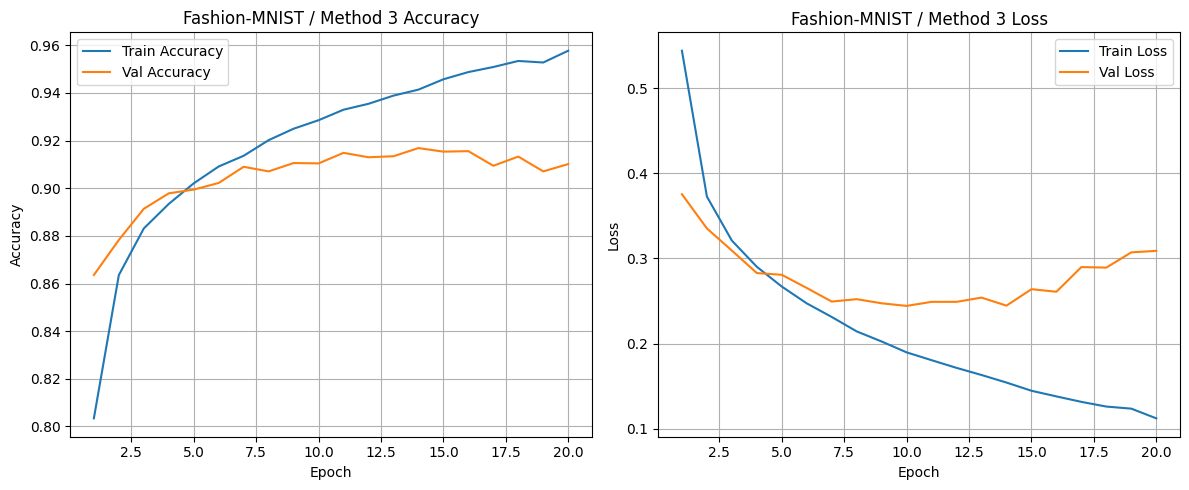



Fashion-MNIST - Method 4
------------------------
Epoch 1/20
875/875 - 5s - 6ms/step - accuracy: 0.7193 - loss: 0.7600 - val_accuracy: 0.7899 - val_loss: 0.5851
Epoch 2/20
875/875 - 4s - 5ms/step - accuracy: 0.7896 - loss: 0.5644 - val_accuracy: 0.8016 - val_loss: 0.5578
Epoch 3/20
875/875 - 4s - 5ms/step - accuracy: 0.8106 - loss: 0.5084 - val_accuracy: 0.8239 - val_loss: 0.4917
Epoch 4/20
875/875 - 4s - 5ms/step - accuracy: 0.8277 - loss: 0.4653 - val_accuracy: 0.8441 - val_loss: 0.4433
Epoch 5/20
875/875 - 4s - 5ms/step - accuracy: 0.8389 - loss: 0.4361 - val_accuracy: 0.8594 - val_loss: 0.4032
Epoch 6/20
875/875 - 4s - 5ms/step - accuracy: 0.8441 - loss: 0.4167 - val_accuracy: 0.8421 - val_loss: 0.4350
Epoch 7/20
875/875 - 4s - 5ms/step - accuracy: 0.8524 - loss: 0.3971 - val_accuracy: 0.8629 - val_loss: 0.3746
Epoch 8/20
875/875 - 4s - 5ms/step - accuracy: 0.8590 - loss: 0.3812 - val_accuracy: 0.8539 - val_loss: 0.3995
Epoch 9/20
875/875 - 4s - 5ms/step - accuracy: 0.8621 - loss

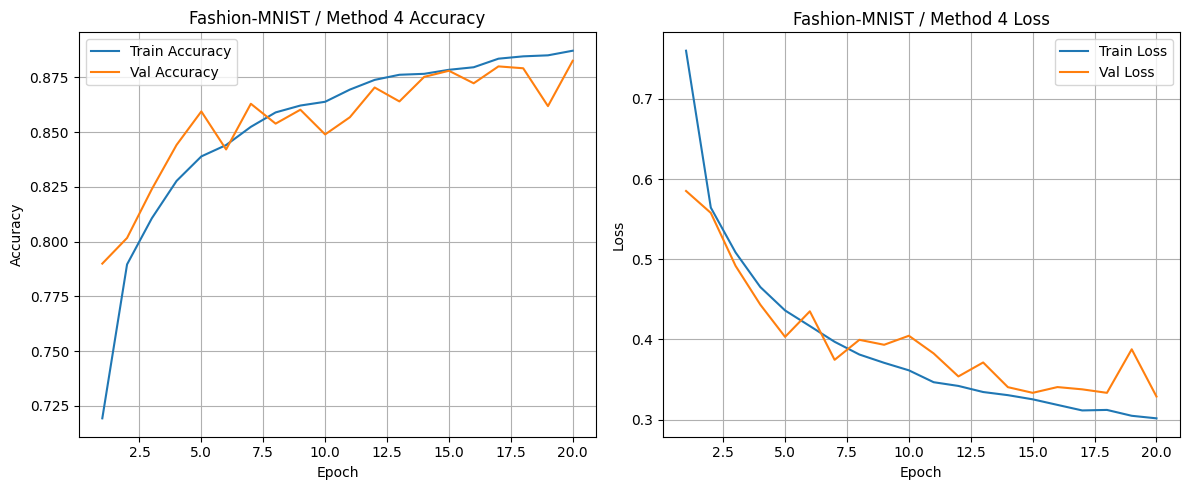



Fashion-MNIST - Method 5
------------------------
Epoch 1/20
875/875 - 5s - 6ms/step - accuracy: 0.7884 - loss: 0.8153 - val_accuracy: 0.8589 - val_loss: 0.4049
Epoch 2/20
875/875 - 4s - 5ms/step - accuracy: 0.8444 - loss: 0.6474 - val_accuracy: 0.8806 - val_loss: 0.3391
Epoch 3/20
875/875 - 4s - 5ms/step - accuracy: 0.8560 - loss: 0.5943 - val_accuracy: 0.8941 - val_loss: 0.3038
Epoch 4/20
875/875 - 4s - 5ms/step - accuracy: 0.8640 - loss: 0.5607 - val_accuracy: 0.9011 - val_loss: 0.2851
Epoch 5/20
875/875 - 4s - 5ms/step - accuracy: 0.8721 - loss: 0.5380 - val_accuracy: 0.9014 - val_loss: 0.2801
Epoch 6/20
875/875 - 4s - 5ms/step - accuracy: 0.8781 - loss: 0.5205 - val_accuracy: 0.9045 - val_loss: 0.2728
Epoch 7/20
875/875 - 4s - 5ms/step - accuracy: 0.8808 - loss: 0.5049 - val_accuracy: 0.9070 - val_loss: 0.2663
Epoch 8/20
875/875 - 4s - 5ms/step - accuracy: 0.8870 - loss: 0.4852 - val_accuracy: 0.9051 - val_loss: 0.2701
Epoch 9/20
875/875 - 4s - 5ms/step - accuracy: 0.8911 - loss

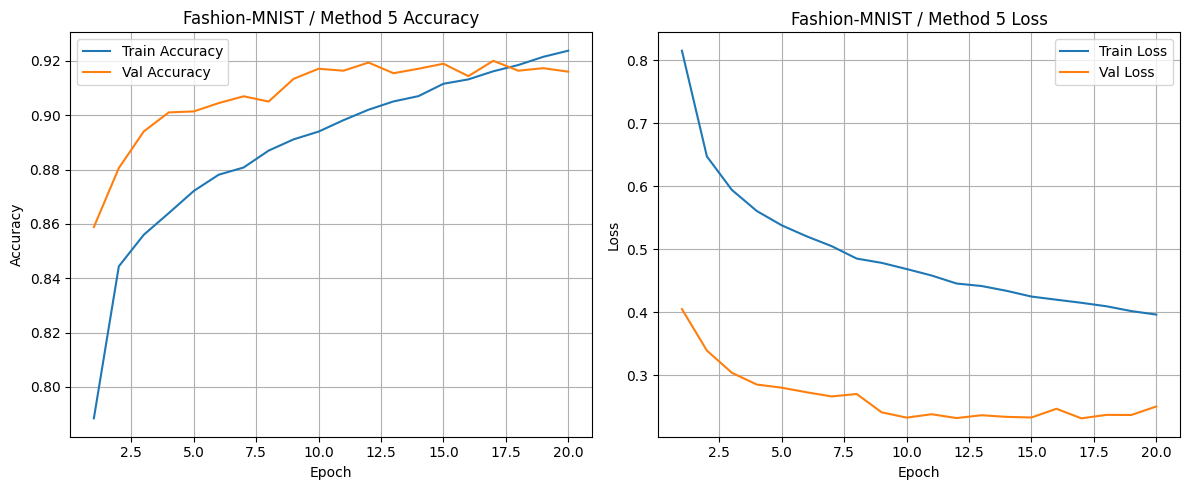



Fashion-MNIST - Method 6
------------------------
Epoch 1/20
875/875 - 5s - 6ms/step - accuracy: 0.6632 - loss: 1.2810 - val_accuracy: 0.8554 - val_loss: 0.4744
Epoch 2/20
875/875 - 4s - 5ms/step - accuracy: 0.7284 - loss: 1.1112 - val_accuracy: 0.8818 - val_loss: 0.3811
Epoch 3/20
875/875 - 4s - 5ms/step - accuracy: 0.7441 - loss: 1.0494 - val_accuracy: 0.8895 - val_loss: 0.3715
Epoch 4/20
875/875 - 4s - 5ms/step - accuracy: 0.7544 - loss: 1.0146 - val_accuracy: 0.8951 - val_loss: 0.3398
Epoch 5/20
875/875 - 4s - 5ms/step - accuracy: 0.7577 - loss: 0.9903 - val_accuracy: 0.8979 - val_loss: 0.3135
Epoch 6/20
875/875 - 4s - 5ms/step - accuracy: 0.7653 - loss: 0.9694 - val_accuracy: 0.8913 - val_loss: 0.3351
Epoch 7/20
875/875 - 4s - 5ms/step - accuracy: 0.7688 - loss: 0.9591 - val_accuracy: 0.9006 - val_loss: 0.3146
Epoch 8/20
875/875 - 4s - 5ms/step - accuracy: 0.7719 - loss: 0.9465 - val_accuracy: 0.9086 - val_loss: 0.2900
Epoch 9/20
875/875 - 4s - 5ms/step - accuracy: 0.7747 - loss

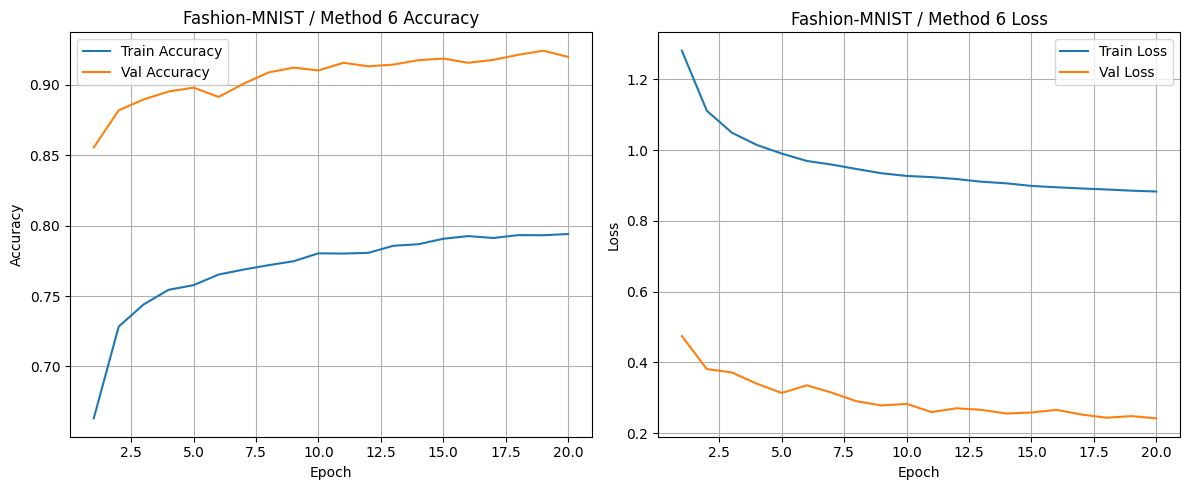



Fashion-MNIST - Method 7
------------------------
Epoch 1/20
875/875 - 8s - 9ms/step - accuracy: 0.5693 - loss: 1.2091 - val_accuracy: 0.8188 - val_loss: 0.5037
Epoch 2/20
875/875 - 7s - 8ms/step - accuracy: 0.6925 - loss: 0.8713 - val_accuracy: 0.8609 - val_loss: 0.3959
Epoch 3/20
875/875 - 8s - 9ms/step - accuracy: 0.7271 - loss: 0.7720 - val_accuracy: 0.8751 - val_loss: 0.3562
Epoch 4/20
875/875 - 8s - 9ms/step - accuracy: 0.7491 - loss: 0.7053 - val_accuracy: 0.8716 - val_loss: 0.3649
Epoch 5/20
875/875 - 7s - 8ms/step - accuracy: 0.7590 - loss: 0.6765 - val_accuracy: 0.8753 - val_loss: 0.3486
Epoch 6/20
875/875 - 7s - 8ms/step - accuracy: 0.7633 - loss: 0.6669 - val_accuracy: 0.8726 - val_loss: 0.3584
Epoch 7/20
875/875 - 8s - 9ms/step - accuracy: 0.7733 - loss: 0.6369 - val_accuracy: 0.8836 - val_loss: 0.3185
Epoch 8/20
875/875 - 8s - 9ms/step - accuracy: 0.7844 - loss: 0.6000 - val_accuracy: 0.8890 - val_loss: 0.3113
Epoch 9/20
875/875 - 8s - 9ms/step - accuracy: 0.7868 - loss

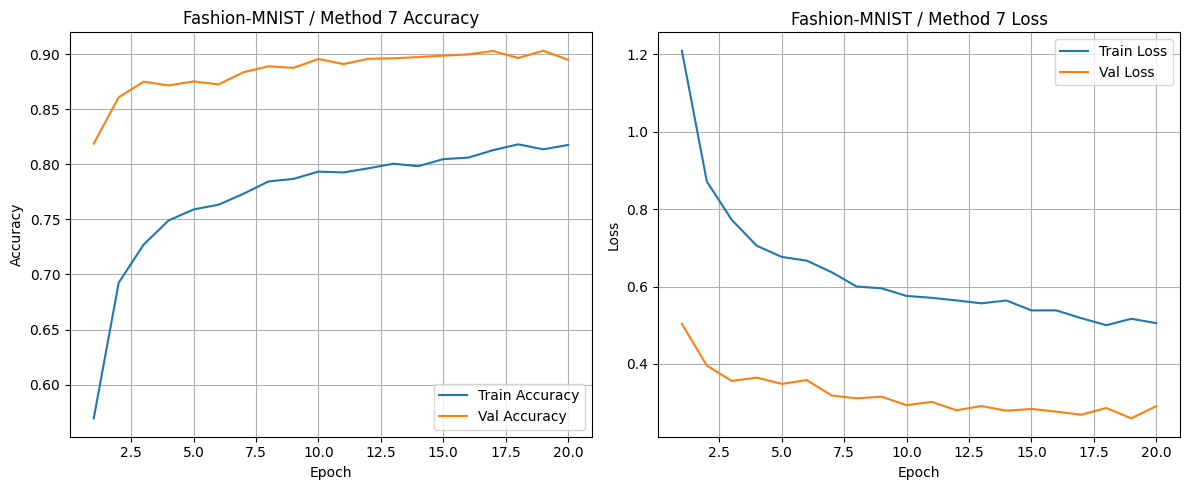


Final accuracy summary (Fashion-MNIST):
Method 0: train_acc=0.9837, val_acc=0.9118
Method 1: train_acc=0.9257, val_acc=0.9051
Method 2: train_acc=0.9245, val_acc=0.9139
Method 3: train_acc=0.9577, val_acc=0.9101
Method 4: train_acc=0.8872, val_acc=0.8826
Method 5: train_acc=0.9238, val_acc=0.9161
Method 6: train_acc=0.7940, val_acc=0.9197
Method 7: train_acc=0.8176, val_acc=0.8949


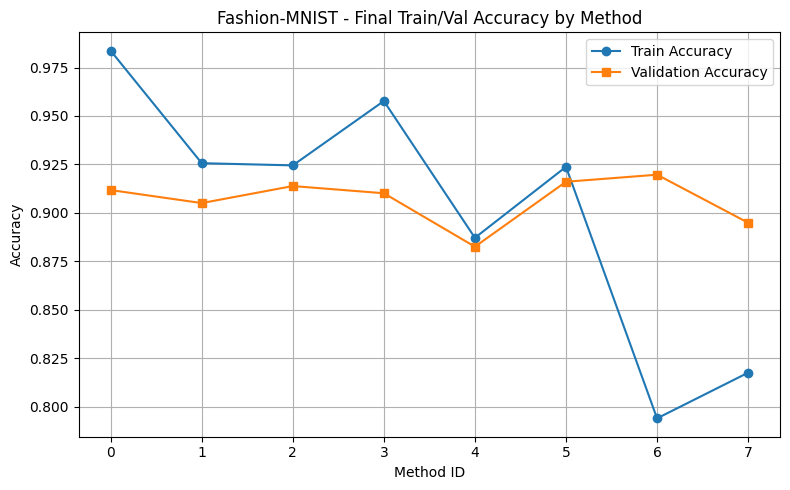

In [3]:
(X0, y0), (X1, y1) = fashion_mnist.load_data()
X = np.concatenate([X0, X1], axis=0)
y = np.concatenate([y0, y1], axis=0)

# float32 + [0,1]
X = X.astype("float32") / 255.0

# (N, 28, 28, 1)
X = X[..., None]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)

input_shape = (28, 28, 1)
num_classes = 10
is_rgb = False

results = {}

for method_id in range(8):
    print("\n")
    print(f"Fashion-MNIST - Method {method_id}")
    print("------------------------")

    history, train_acc, val_acc = run_method(
        X_train, y_train, X_val, y_val,
        input_shape=input_shape,
        num_classes=num_classes,
        method_id=method_id,
        is_rgb=is_rgb
    )

    results[method_id] = (train_acc, val_acc)
    plot_acc_loss(history, title_prefix=f"Fashion-MNIST / Method {method_id}")

print("\nFinal accuracy summary (Fashion-MNIST):")
for k in range(8):
    ta, va = results[k]
    print(f"Method {k}: train_acc={ta:.4f}, val_acc={va:.4f}")

plot_final_summary(results, title="Fashion-MNIST - Final Train/Val Accuracy by Method")